# Assignment 1 — Data Wrangling on weight-height Dataset

## Topic Explanation

**Data Wrangling** (also called *data cleaning* or *data munging*) is the process of taking raw, messy, real-world data and transforming it into a clean, structured form ready for analysis. In any real data-science project, this step typically takes **60–80% of the total time** — far more than the modeling itself. The famous saying among data scientists is **"garbage in, garbage out"** — even the most sophisticated machine learning algorithm will produce useless results if you feed it dirty data.

In this assignment we focus on **three core problems**:

### 1. Missing Values & Inconsistencies

A **missing value** is a cell where data should exist but doesn't — represented as `NaN` (Not a Number) in pandas. There are three options for handling it:
- **Drop** the row entirely
- **Impute** with a statistic like mean, median, or mode
- **Predict** the missing value from other features (advanced)

We use **median imputation** because it's robust to outliers (the mean can be dragged by a single extreme value, but the median can't).

An **inconsistency** is a value that's *present* but *invalid* in some way:
- **Format inconsistency** — same idea written differently (`M`, `Male`, `male`, `MALE` all mean the same thing)
- **Range inconsistency** — value outside the physically possible range (height of −5 inches)

### 2. Outliers

An **outlier** is a value that lies far away from the rest of the data without necessarily being invalid. We detect outliers using the **IQR Rule**:
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 − Q1
- Outlier if value < Q1 − 1.5·IQR or value > Q3 + 1.5·IQR

We treat outliers using **winsorization (capping)** — replacing extreme values with the IQR boundary instead of removing them.

### 3. Data Transformation

A **transformation** is a mathematical operation applied to a variable to change its shape or scale. We apply a **log transformation** to reduce **right-skewness** in Weight, making the distribution more symmetric (closer to normal).

The `weight-height` dataset contains: **Gender** (Male/Female), **Height** (inches), **Weight** (pounds).

## Step 1: Import Libraries

In [2]:
# pandas — DataFrame operations (loading, filtering, statistics)
import pandas as pd

# numpy — numerical operations; provides np.nan and mathematical functions like log1p
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline in the notebook
%matplotlib inline

# Set seaborn style for cleaner-looking plots
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

In [3]:
# read_csv() loads a CSV file into a pandas DataFrame.
df = pd.read_csv('/home/nishant/LOCAL_DISK_D/10/dataset/weight_height.csv')

# shape returns (rows, columns)
print("Shape:", df.shape)

# head() shows the first 5 rows for quick inspection
df.head()

Shape: (200, 3)


,Gender,Height,Weight
0,Male,67.35,165.97
1,Female,65.80,141.99
2,Male,67.37,162.09
3,Male,59.05,148.44
4,Male,66.12,163.41


In [3]:
# info() — column names, non-null counts, data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  200 non-null    str    
 1   Height  199 non-null    float64
 2   Weight  199 non-null    float64
dtypes: float64(2), str(1)
memory usage: 4.8 KB


In [4]:
# describe() — summary statistics for numeric columns
df.describe()

,Height,Weight
count,199.000000,199.000000
mean,66.697035,162.545729
std,6.510363,37.079044
min,-5.000000,90.940000
25%,64.035000,142.020000
50%,67.240000,160.380000
75%,69.520000,179.975000
max,82.410000,500.000000


## Operation 1 — Missing Values & Inconsistencies

We tackle this in two parts:
- **3.1 Missing values** — empty cells detected with `isnull()`
- **3.2 Inconsistencies** — values that are present but invalid

### 3.1 Detect Missing Values

In [5]:
# isnull() returns a boolean DataFrame; sum() counts True values per column
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing cells:", df.isnull().sum().sum())

Missing values per column:
Gender    0
Height    1
Weight    1
dtype: int64

Total missing cells: 2


### 3.2 Detect Inconsistencies — Gender Column

In [6]:
# unique() shows the distinct values in the column
print("Unique Gender values BEFORE cleaning:")
print(df['Gender'].unique())

print("\nValue counts:")
print(df['Gender'].value_counts())

Unique Gender values BEFORE cleaning:
<StringArray>
['Male', 'Female', 'M', 'female']
Length: 4, dtype: str

Value counts:
Gender
Female    100
Male       98
M           1
female      1
Name: count, dtype: int64


### 3.3 Standardize Gender Values

In [7]:
# Step 1: strip whitespace
# Step 2: convert to lowercase
# Step 3: map all variants to clean labels
df['Gender'] = (df['Gender']
                .str.strip()
                .str.lower()
                .map({'m': 'Male', 'male': 'Male',
                      'f': 'Female', 'female': 'Female'}))

print("Unique Gender values AFTER cleaning:")
print(df['Gender'].unique())
print("\nValue counts:")
print(df['Gender'].value_counts())

Unique Gender values AFTER cleaning:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Value counts:
Gender
Female    101
Male       99
Name: count, dtype: int64


### 3.4 Detect Invalid Numeric Values

In [8]:
# Height should be positive — flag negative values as invalid
print("Invalid Height values (< 0):")
print(df[df['Height'] < 0])

Invalid Height values (< 0):
    Gender  Height  Weight
20  Female    -5.0  186.99


### 3.5 Replace Invalid Values with NaN, Then Fill

In [9]:
# Mark invalid heights as NaN, so they can be imputed like any other missing value
df.loc[df['Height'] < 0, 'Height'] = np.nan

print("Missing values after flagging invalid entries:")
print(df.isnull().sum())

Missing values after flagging invalid entries:
Gender    0
Height    2
Weight    1
dtype: int64


In [10]:
# Use MEDIAN imputation — robust to outliers
# (mean would be dragged by extreme values; median ignores them)
df['Height'].fillna(df['Height'].median(), inplace=True)
df['Weight'].fillna(df['Weight'].median(), inplace=True)

print("Missing values after imputation:", df.isnull().sum().sum())
df.head()

Missing values after imputation: 3


/tmp/ipykernel_532/640832872.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Height'].fillna(df['Height'].median(), inplace=True)
/tmp/ipykernel_532/640832872.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never work

,Gender,Height,Weight
0,Male,67.35,165.97
1,Female,65.80,141.99
2,Male,67.37,162.09
3,Male,59.05,148.44
4,Male,66.12,163.41


## Operation 2 — Outlier Detection & Treatment

An **outlier** is a value far from the rest of the data. We:
1. Visualize using **boxplots**
2. Detect using the **IQR rule** (Q1 − 1.5·IQR, Q3 + 1.5·IQR)
3. Treat by **capping (winsorization)** — replacing extreme values with IQR bounds

### 4.1 Visualize Outliers — Boxplots BEFORE Treatment

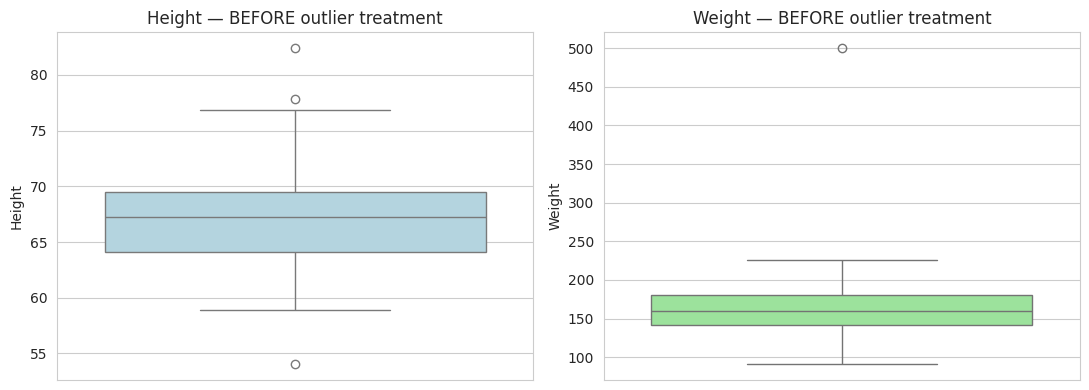

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df['Height'], ax=ax[0], color='lightblue')
ax[0].set_title('Height — BEFORE outlier treatment')

sns.boxplot(y=df['Weight'], ax=ax[1], color='lightgreen')
ax[1].set_title('Weight — BEFORE outlier treatment')

plt.tight_layout()
plt.show()

### 4.2 Detect Outliers Numerically (IQR Method)

In [12]:
def detect_outliers(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"{name}: bounds=[{lower:.2f}, {upper:.2f}], outlier count = {len(outliers)}")
    return outliers

detect_outliers(df['Height'], 'Height')
detect_outliers(df['Weight'], 'Weight')

Height: bounds=[55.94, 77.68], outlier count = 3
Weight: bounds=[85.09, 236.91], outlier count = 1


30    500.0
Name: Weight, dtype: float64

### 4.3 Cap Outliers (Winsorization)

In [13]:
def cap_outliers(series):
    """Replace values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] with the boundary values."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

df['Height'] = cap_outliers(df['Height'])
df['Weight'] = cap_outliers(df['Weight'])

print("After capping, outlier counts:")
detect_outliers(df['Height'], 'Height')
detect_outliers(df['Weight'], 'Weight')

After capping, outlier counts:
Height: bounds=[55.94, 77.68], outlier count = 0
Weight: bounds=[85.09, 236.91], outlier count = 0


Series([], Name: Weight, dtype: float64)

### 4.4 Boxplots AFTER Treatment

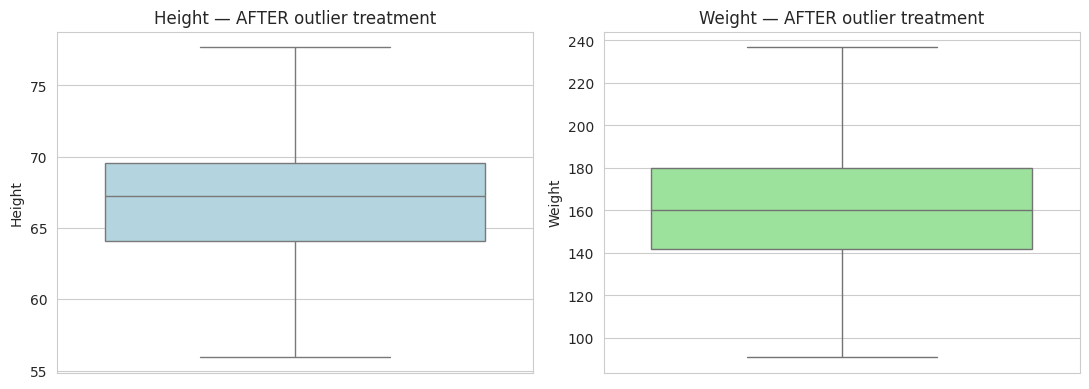

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df['Height'], ax=ax[0], color='lightblue')
ax[0].set_title('Height — AFTER outlier treatment')

sns.boxplot(y=df['Weight'], ax=ax[1], color='lightgreen')
ax[1].set_title('Weight — AFTER outlier treatment')

plt.tight_layout()
plt.show()

## Operation 3 — Data Transformation

We apply a **log transformation** to reduce skewness in Weight.

**Why?** Many statistical methods (regression, t-tests, ANOVA) assume the data is roughly bell-shaped. Right-skewed data violates that assumption.

**How?** `np.log1p(x) = log(1 + x)` — handles zero values safely (since `log(0)` is undefined).

### 5.1 Check Skewness Before Transformation

In [15]:
# .skew() returns a number describing distribution asymmetry:
#   skew == 0  -> symmetric (normal)
#   skew  > 0  -> right-skewed (tail on right)
#   skew  < 0  -> left-skewed
print(f"Skewness of Height: {df['Height'].skew():.4f}")
print(f"Skewness of Weight: {df['Weight'].skew():.4f}")

Skewness of Height: 0.2015
Skewness of Weight: 0.1147


### 5.2 Original Distribution Plots

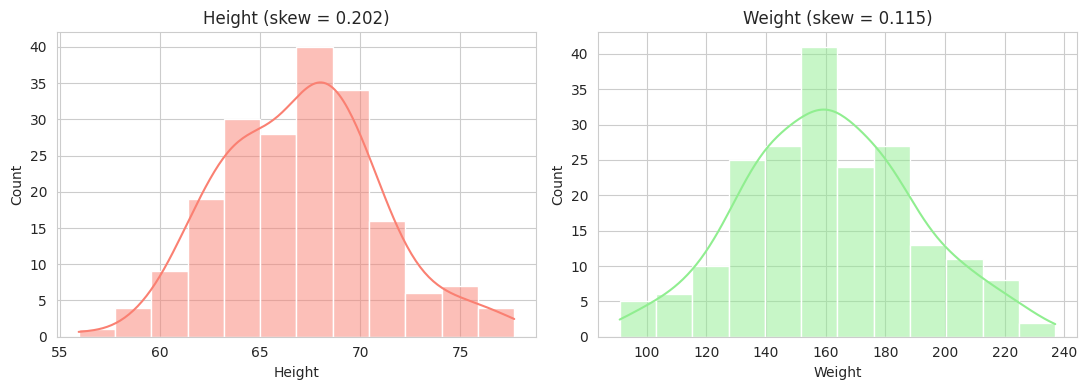

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['Height'], kde=True, color='salmon', ax=ax[0])
ax[0].set_title(f"Height (skew = {df['Height'].skew():.3f})")

sns.histplot(df['Weight'], kde=True, color='lightgreen', ax=ax[1])
ax[1].set_title(f"Weight (skew = {df['Weight'].skew():.3f})")

plt.tight_layout()
plt.show()

### 5.3 Apply Log Transformation

In [17]:
# log1p(x) = log(1 + x); safe for zero values
df['Weight_log'] = np.log1p(df['Weight'])

print(f"Skewness BEFORE log: {df['Weight'].skew():.4f}")
print(f"Skewness AFTER  log: {df['Weight_log'].skew():.4f}")
print(f"\nSkewness reduced from {df['Weight'].skew():.4f} toward 0 (more symmetric).")

Skewness BEFORE log: 0.1147
Skewness AFTER  log: -0.3927

Skewness reduced from 0.1147 toward 0 (more symmetric).


### 5.4 Compare Distributions Before vs After

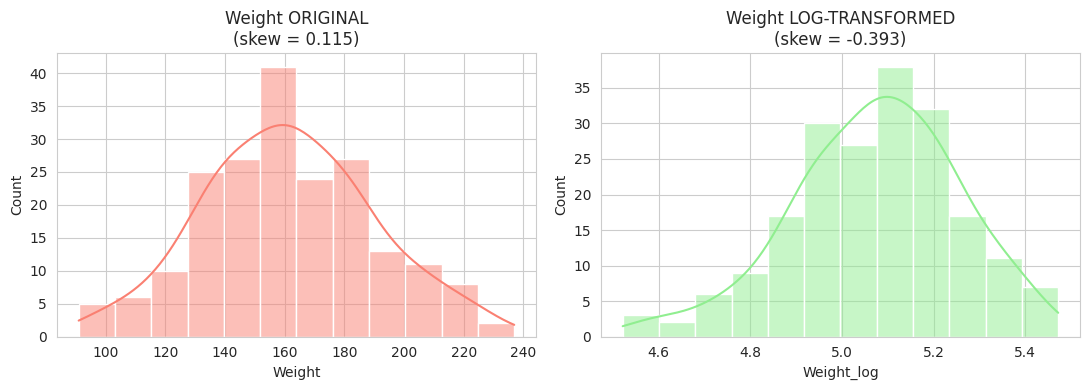

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['Weight'], kde=True, color='salmon', ax=ax[0])
ax[0].set_title(f"Weight ORIGINAL\n(skew = {df['Weight'].skew():.3f})")

sns.histplot(df['Weight_log'], kde=True, color='lightgreen', ax=ax[1])
ax[1].set_title(f"Weight LOG-TRANSFORMED\n(skew = {df['Weight_log'].skew():.3f})")

plt.tight_layout()
plt.show()

### 5.5 Other Transformations (For Reference)

In [19]:
# Demonstrate three more transformation techniques

# Square root — milder than log
df['Weight_sqrt'] = np.sqrt(df['Weight'])

# Min-Max scaling — rescales values to [0, 1]
df['Weight_minmax'] = (df['Weight'] - df['Weight'].min()) / \
                       (df['Weight'].max() - df['Weight'].min())

# Z-score (Standardization) — centers on 0 with std = 1
df['Weight_zscore'] = (df['Weight'] - df['Weight'].mean()) / df['Weight'].std()

# Compare skewness
comparison = pd.DataFrame({
    'Original': [df['Weight'].skew()],
    'Log':      [df['Weight_log'].skew()],
    'Sqrt':     [df['Weight_sqrt'].skew()],
    'Min-Max':  [df['Weight_minmax'].skew()],
    'Z-score':  [df['Weight_zscore'].skew()],
}, index=['Skewness']).round(4)

print("Skewness comparison across transformations:")
comparison

Skewness comparison across transformations:


,Original,Log,Sqrt,Min-Max,Z-score
Skewness,0.1147,-0.3927,-0.1337,0.1147,0.1147


## Step 6: Final Cleaned and Transformed DataFrame

In [20]:
print("Final shape:", df.shape)
print("\nFinal data types:")
print(df.dtypes)
print("\nPreview of cleaned data:")
df.head(10)

Final shape: (200, 7)

Final data types:
Gender               str
Height           float64
Weight           float64
Weight_log       float64
Weight_sqrt      float64
Weight_minmax    float64
Weight_zscore    float64
dtype: object

Preview of cleaned data:


,Gender,Height,Weight,Weight_log,Weight_sqrt,Weight_minmax,Weight_zscore
0,Male,67.35,165.97,5.117814,12.882934,0.514019,0.165157
1,Female,65.80,141.99,4.962775,11.915956,0.349735,-0.669266
2,Male,67.37,162.09,5.094302,12.731457,0.487437,0.030146
3,Male,59.05,148.44,5.006895,12.183596,0.393923,-0.444828
4,Male,66.12,163.41,5.102363,12.783192,0.496480,0.076077
5,Female,NaN,179.86,5.197723,13.411189,0.609177,0.648481
6,Male,72.91,207.58,5.340323,14.407637,0.799082,1.613043
7,Male,64.93,122.87,4.819233,11.084674,0.218747,-1.334577
8,Male,63.77,223.99,5.416056,14.966295,0.911504,2.184055
9,Female,64.99,101.44,4.629277,10.071743,0.071934,-2.080268


## Conclusion

We performed three data-wrangling operations on `weight_height.csv`:

1. **Missing values & inconsistencies** — counted NaNs with `isnull().sum()`; standardized inconsistent gender spellings (`M`, `Male`, `male`, `MALE`, etc.) into clean `Male`/`Female`; flagged invalid heights (negative values) as NaN; filled all missing values with the column **median** (robust to outliers).

2. **Outliers** — visualized with **boxplots**; detected numerically using the **IQR rule**; capped them via **winsorization** so all rows are preserved.

3. **Transformation** — applied **log1p** to Weight to reduce right-skewness; verified skewness decreased toward zero, producing a more normal distribution. Demonstrated sqrt, Min-Max, and Z-score scaling as additional techniques.

The final DataFrame has no missing values, no extreme outliers, and a more symmetric Weight distribution — ready for downstream analysis or modeling.

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | Tabular data handling — DataFrames, reading CSVs, group operations, missing-value handling |
| **numpy** | Numerical computing — `np.nan`, `log1p`, `sqrt`, mathematical operations |
| **matplotlib.pyplot** | Base plotting — figure size, titles, axes |
| **seaborn** | Statistical visualization built on matplotlib — cleaner plots |

### Functions and Methods Used

#### Data Loading & Inspection
- `pd.read_csv(path)` — read CSV into DataFrame
- `df.shape` — `(rows, columns)`
- `df.head(n)` — first n rows (default 5)
- `df.info()` — column names, non-null counts, dtypes
- `df.describe()` — summary statistics for numeric columns
- `df.dtypes` — data type of each column

#### Missing Value Handling
- `df.isnull()` — boolean DataFrame; True where NaN
- `.sum()` — counts True values
- `df['col'].unique()` — unique values in column
- `df['col'].value_counts()` — count occurrences
- `df['col'].fillna(value, inplace=True)` — replace NaN
- `df['col'].median()` — middle value; robust to outliers
- `df.loc[condition, 'col'] = value` — conditional assignment

#### String Cleaning
- `.str.strip()` — removes whitespace
- `.str.lower()` — lowercase
- `.map({old: new})` — replace via dictionary

#### Outlier Detection & Treatment
- `df['col'].quantile(0.25)` — 25th percentile (Q1)
- `df['col'].quantile(0.75)` — 75th percentile (Q3)
- **IQR rule** — outlier if value < Q1 − 1.5·IQR or > Q3 + 1.5·IQR
- `series.clip(lower, upper)` — caps values to range

#### Transformations
- `np.log1p(x)` — `log(1 + x)`; safe for zero
- `np.sqrt(x)` — square root
- **Min-Max** — `(x − min)/(max − min)` rescales to [0, 1]
- **Z-score** — `(x − mean)/std` centers on 0 with std 1
- `df['col'].skew()` — distribution asymmetry

#### Visualization
- `sns.boxplot(y=...)` — box-and-whisker plot
- `sns.histplot(x, kde=True)` — histogram with smooth density curve
- `plt.subplots(rows, cols, figsize=(w, h))` — grid of plots
- `plt.tight_layout()` — prevents overlap
- `plt.show()` — render figure

### Key Concepts Explained

#### Median Imputation
Filling missing values with the column's **median**. We chose median over mean because the mean is dragged by extreme outliers; the median is **robust** — a single 9999 outlier won't shift it.

#### IQR Rule
The **Interquartile Range** is the spread of the middle 50% of data: IQR = Q3 − Q1. Tukey's rule defines a value as an outlier if it lies more than 1.5×IQR below Q1 or above Q3. The 1.5 multiplier flags about 0.7% of normal-distribution values.

#### Winsorization (Capping)
Replacing outliers with the IQR boundary instead of dropping them. Preserves all rows — important for small datasets.

#### Skewness
A number describing distribution asymmetry:
- **0** → symmetric (bell-shaped)
- **> 0** → right-skewed (long tail on right; mean > median)
- **< 0** → left-skewed (long tail on left; mean < median)
- **|skew| > 1** → strongly skewed

#### Log Transformation
Applying `log()` (or `log1p()`) to a right-skewed variable to compress the long tail and pull the distribution toward symmetry. Helpful because many statistical methods (linear regression, t-tests) assume normality.

#### Why `log1p` not `log`?
`log(0)` is undefined (−∞). `log1p(x) = log(1 + x)` returns 0 for input 0 — safe for any non-negative data including zeros.

#### Min-Max Scaling
Rescales values to [0, 1] via `(x − min)/(max − min)`. Preserves shape; only changes range.

#### Z-score Standardization
Transforms values to mean = 0, std = 1, via `(x − mean)/std`. Common preprocessing for ML algorithms sensitive to scale.

## Viva Questions (with Answers)

**Q1. What is data wrangling?**
The process of cleaning and preparing raw data for analysis — handling missing values, inconsistencies, outliers, and applying transformations. Typically takes 60–80% of any data science project.

**Q2. Why use median instead of mean for imputation?**
Median is **robust to outliers**; mean is dragged by extreme values. If your data has even one extreme value, the mean will be distorted but the median will not.

**Q3. What is the IQR method?**
Compute Q1 (25th percentile) and Q3 (75th percentile). IQR = Q3 − Q1. A value is an outlier if it's below Q1 − 1.5·IQR or above Q3 + 1.5·IQR.

**Q4. What is winsorization?**
Capping outliers at the IQR boundary instead of removing them. Preserves all rows while constraining extreme values.

**Q5. Why cap rather than drop outliers?**
- Capping preserves all rows (better for small datasets)
- Dropping loses information and may bias results
- Outliers might be real values, not data errors

**Q6. What is skewness?**
A number describing distribution asymmetry. Zero = symmetric. Positive = right-skewed (tail on right). Negative = left-skewed.

**Q7. Why apply a log transformation?**
To reduce right-skewness and bring the distribution closer to normal. Many statistical/ML methods assume normality, so log makes the data more compatible with them.

**Q8. Why `np.log1p()` instead of `np.log()`?**
`log(0)` is undefined (−∞). `log1p(x) = log(1+x)` handles zero values safely.

**Q9. Difference between Min-Max scaling and Standardization?**
- **Min-Max**: rescales to [0, 1] via `(x − min)/(max − min)` — preserves shape
- **Standardization (Z-score)**: centers on 0 with std = 1 via `(x − mean)/std` — better for normally distributed data

**Q10. What does the box in a boxplot represent?**
The middle 50% of the data — from Q1 (bottom) to Q3 (top). The line inside is the median.

**Q11. What are whiskers in a boxplot?**
Lines extending from the box to the smallest and largest values within 1.5×IQR. Anything beyond is shown as outlier dots.

**Q12. What does `.clip(lower, upper)` do?**
Replaces any values below `lower` with `lower`, and any values above `upper` with `upper`. The middle range is unchanged. Used here for capping outliers.

**Q13. Difference between `dropna()` and `fillna()`?**
- `dropna()` — removes rows containing NaN
- `fillna(value)` — replaces NaN with a specified value

**Q14. Why are inconsistencies a problem for ML models?**
ML models treat each unique string as a separate category. So `'Male'`, `'male'`, and `'M'` would be treated as 3 different genders, fragmenting information and reducing model accuracy.

**Q15. What other transformation techniques exist besides log?**
- Square root (mild skew)
- Reciprocal (1/x; strong skew correction)
- Box-Cox (auto-picks best power)
- Yeo-Johnson (works for negative values)
- Min-Max scaling (rescale to [0, 1])
- Standardization (mean 0, std 1)